In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [6]:
def cargar_archivo(ruta):
    try:
        df = pd.read_csv(ruta)

        if df.empty:
            print("El archivo está vacío.")
            return None

        print("Archivo cargado correctamente.")
        return df

    except FileNotFoundError:
        print("Error: el archivo no existe.")

    except pd.errors.EmptyDataError:
        print("Error: el archivo está vacío.")

    except pd.errors.ParserError:
        print("Error: el archivo CSV no se puede interpretar.")

In [7]:
df = cargar_archivo("mantenimientos.csv")

if df is not None:
    print(df.head())

Archivo cargado correctamente.
     codigo     equipo tipo_mantenimiento    area       fecha   costo  \
0  MNT-0001     Switch         Preventivo  FADCOM  2026-03-16   56.64   
1  MNT-0002     Router         Preventivo    GTSI  2026-01-28   53.86   
2  MNT-0003  Proyector         Preventivo   FIMCP  2026-03-17   83.42   
3  MNT-0004    Desktop         Preventivo    FCNM  2026-01-31   79.54   
4  MNT-0005     Switch         Correctivo    GTSI  2026-04-11  117.38   

   duracion_horas       tecnico      estado  satisfaccion  
0             1.9    Ana Torres  En proceso             5  
1             2.3    Sofia Leon  Completado             1  
2             1.4  Maria Cedeño  Completado             5  
3             1.7    Ana Torres  Completado             5  
4             2.7    Ana Torres  Completado             4  


In [8]:
# Validar códigos vacíos
codigos_vacios = df["codigo"].isna() | (df["codigo"].astype(str).str.strip() == "")

print("Códigos vacíos:", codigos_vacios.sum())

# Validar códigos duplicados
codigos_duplicados = df["codigo"].duplicated()

print("Códigos duplicados:", codigos_duplicados.sum())

Códigos vacíos: 0
Códigos duplicados: 0


In [9]:
# Convertir la columna fecha a formato fecha
fechas_convertidas = pd.to_datetime(df["fecha"], errors="coerce")

# Detectar fechas inválidas
fechas_invalidas = fechas_convertidas.isna()

print("Fechas inválidas:", fechas_invalidas.sum())

Fechas inválidas: 0


In [11]:
fechas_convertidas = pd.to_datetime(df["fecha"], errors="coerce")

In [12]:
# Convertir los costos a números
costos_convertidos = pd.to_numeric(df["costo"], errors="coerce")

# Detectar costos no numéricos
costos_no_numericos = costos_convertidos.isna()

# Detectar costos negativos
costos_negativos = costos_convertidos < 0

print("Costos no numéricos:", costos_no_numericos.sum())
print("Costos negativos:", costos_negativos.sum())

Costos no numéricos: 0
Costos negativos: 0


In [13]:
# Convertir las duraciones a números
duraciones_convertidas = pd.to_numeric(df["duracion_horas"], errors="coerce")

# Detectar duraciones no numéricas
duraciones_no_numericas = duraciones_convertidas.isna()

# Detectar duraciones iguales o menores a cero
duraciones_no_positivas = duraciones_convertidas <= 0

print("Duraciones no numéricas:", duraciones_no_numericas.sum())
print("Duraciones no positivas:", duraciones_no_positivas.sum())

Duraciones no numéricas: 0
Duraciones no positivas: 0


In [14]:
# Convertir satisfacción a número
satisfaccion_convertida = pd.to_numeric(df["satisfaccion"], errors="coerce")

# Detectar valores fuera del rango de 1 a 5
satisfaccion_invalida = (
    satisfaccion_convertida.isna() |
    (satisfaccion_convertida < 1) |
    (satisfaccion_convertida > 5)
)

print("Satisfacción fuera del rango 1 a 5:", satisfaccion_invalida.sum())

Satisfacción fuera del rango 1 a 5: 0


In [15]:
# Estados permitidos
estados_permitidos = ["Completado", "En proceso", "Pendiente"]

# Detectar estados no permitidos
estados_invalidos = ~df["estado"].isin(estados_permitidos)

print("Estados no permitidos:", estados_invalidos.sum())

Estados no permitidos: 0


In [16]:
print(df["equipo"].unique())

['Switch' 'Router' 'Proyector' 'Desktop' 'Laptop' 'Impresora']


In [17]:
equipos_permitidos = [
    "Switch",
    "Router",
    "Proyector",
    "Desktop",
    "Laptop",
    "Impresora"
]

equipos_invalidos = ~df["equipo"].isin(equipos_permitidos)

print("Categorías de equipo no contempladas:", equipos_invalidos.sum())

Categorías de equipo no contempladas: 0


In [18]:
# Unir todas las condiciones de error
registros_invalidos = (
    codigos_vacios |
    codigos_duplicados |
    fechas_invalidas |
    costos_no_numericos |
    costos_negativos |
    duraciones_no_numericas |
    duraciones_no_positivas |
    satisfaccion_invalida |
    estados_invalidos |
    equipos_invalidos
)

# Crear el DataFrame limpio
df_limpio = df[~registros_invalidos].copy()

# Guardar los valores ya convertidos correctamente
df_limpio["fecha"] = pd.to_datetime(df_limpio["fecha"])
df_limpio["costo"] = pd.to_numeric(df_limpio["costo"])
df_limpio["duracion_horas"] = pd.to_numeric(df_limpio["duracion_horas"])
df_limpio["satisfaccion"] = pd.to_numeric(df_limpio["satisfaccion"])

print("Registros originales:", len(df))
print("Registros inválidos:", registros_invalidos.sum())
print("Registros válidos:", len(df_limpio))

Registros originales: 120
Registros inválidos: 0
Registros válidos: 120


In [20]:
df_limpio.head()

,codigo,equipo,tipo_mantenimiento,area,fecha,costo,duracion_horas,tecnico,estado,satisfaccion
0,MNT-0001,Switch,Preventivo,FADCOM,2026-03-16,56.64,1.9,Ana Torres,En proceso,5
1,MNT-0002,Router,Preventivo,GTSI,2026-01-28,53.86,2.3,Sofia Leon,Completado,1
2,MNT-0003,Proyector,Preventivo,FIMCP,2026-03-17,83.42,1.4,Maria Cedeño,Completado,5
3,MNT-0004,Desktop,Preventivo,FCNM,2026-01-31,79.54,1.7,Ana Torres,Completado,5
4,MNT-0005,Switch,Correctivo,GTSI,2026-04-11,117.38,2.7,Ana Torres,Completado,4


In [21]:
# Convertir los costos a un arreglo de NumPy
costos = df_limpio["costo"].to_numpy()

# Calcular media y mediana
media_costos = np.mean(costos)
mediana_costos = np.median(costos)

print("Media de costos:", round(media_costos, 2))
print("Mediana de costos:", round(mediana_costos, 2))

Media de costos: 84.84
Mediana de costos: 83.96


In [22]:
# Condiciones para clasificar los costos
condiciones = [
    df_limpio["costo"] < 60,
    (df_limpio["costo"] >= 60) & (df_limpio["costo"] <= 100),
    df_limpio["costo"] > 100
]

# Categorías
categorias = ["Bajo", "Medio", "Alto"]

# Crear una nueva columna usando NumPy
df_limpio["clasificacion_costo"] = np.select(
    condiciones,
    categorias,
    default="Sin clasificar"
)

# Mostrar el resultado
df_limpio[["codigo", "costo", "clasificacion_costo"]].head(10)

,codigo,costo,clasificacion_costo
0,MNT-0001,56.64,Bajo
1,MNT-0002,53.86,Bajo
2,MNT-0003,83.42,Medio
3,MNT-0004,79.54,Medio
4,MNT-0005,117.38,Alto
5,MNT-0006,141.88,Alto
6,MNT-0007,65.75,Medio
7,MNT-0008,49.98,Bajo
8,MNT-0009,126.57,Alto
9,MNT-0010,68.02,Medio


In [23]:
# Indicadores generales

numero_mantenimientos = len(df_limpio)

costo_total = df_limpio["costo"].sum()

costo_promedio = df_limpio["costo"].mean()

mantenimiento_mas_costoso = df_limpio.loc[df_limpio["costo"].idxmax()]

print("Número de mantenimientos válidos:", numero_mantenimientos)
print("Costo total: $", round(costo_total, 2))
print("Costo promedio: $", round(costo_promedio, 2))

print("\nMantenimiento más costoso:")
print("Código:", mantenimiento_mas_costoso["codigo"])
print("Equipo:", mantenimiento_mas_costoso["equipo"])
print("Costo: $", mantenimiento_mas_costoso["costo"])

Número de mantenimientos válidos: 120
Costo total: $ 10180.53
Costo promedio: $ 84.84

Mantenimiento más costoso:
Código: MNT-0119
Equipo: Proyector
Costo: $ 172.63


In [24]:
# Cantidad de mantenimientos por área
mantenimientos_por_area = df_limpio.groupby("area").size()

print("Cantidad de mantenimientos por área:")
print(mantenimientos_por_area)

Cantidad de mantenimientos por área:
area
FADCOM    22
FCNM      22
FCSH      28
FIEC      22
FIMCP     13
GTSI      13
dtype: int64


In [25]:
# Costo promedio por tipo de mantenimiento
costo_promedio_por_tipo = df_limpio.groupby("tipo_mantenimiento")["costo"].mean()

print("Costo promedio por tipo de mantenimiento:")
print(costo_promedio_por_tipo.round(2))

Costo promedio por tipo de mantenimiento:
tipo_mantenimiento
Correctivo     117.82
Diagnostico     49.83
Preventivo      61.54
Name: costo, dtype: float64


In [26]:
# Cantidad de mantenimientos por área
mantenimientos_por_area = df_limpio.groupby("area").size()

print("Cantidad de mantenimientos por área:")
print(mantenimientos_por_area)

Cantidad de mantenimientos por área:
area
FADCOM    22
FCNM      22
FCSH      28
FIEC      22
FIMCP     13
GTSI      13
dtype: int64


In [27]:
# Ciclo para recorrer las áreas
for area, cantidad in mantenimientos_por_area.items():

    if cantidad >= 25:
        nivel = "Alta cantidad de mantenimientos"
    elif cantidad >= 20:
        nivel = "Cantidad media de mantenimientos"
    else:
        nivel = "Baja cantidad de mantenimientos"

    print(area, "-", cantidad, "-", nivel)

FADCOM - 22 - Cantidad media de mantenimientos
FCNM - 22 - Cantidad media de mantenimientos
FCSH - 28 - Alta cantidad de mantenimientos
FIEC - 22 - Cantidad media de mantenimientos
FIMCP - 13 - Baja cantidad de mantenimientos
GTSI - 13 - Baja cantidad de mantenimientos


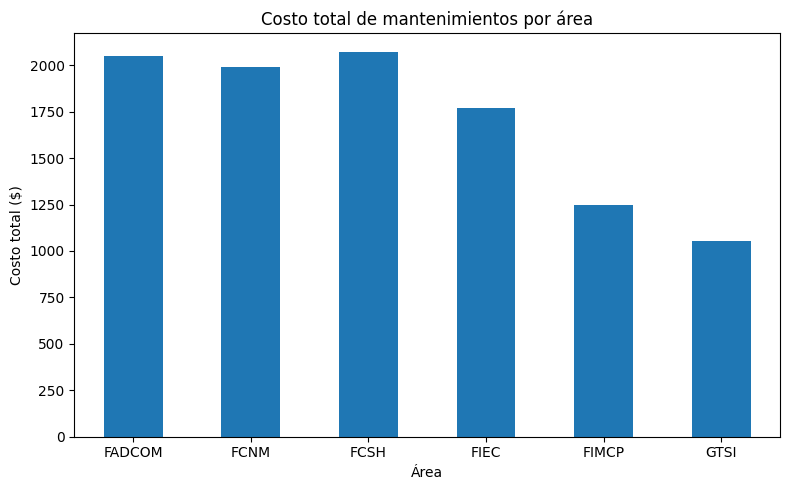

In [28]:
# Calcular el costo total por área
costo_por_area = df_limpio.groupby("area")["costo"].sum()

# Crear gráfico
plt.figure(figsize=(8, 5))
costo_por_area.plot(kind="bar")

plt.title("Costo total de mantenimientos por área")
plt.xlabel("Área")
plt.ylabel("Costo total ($)")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

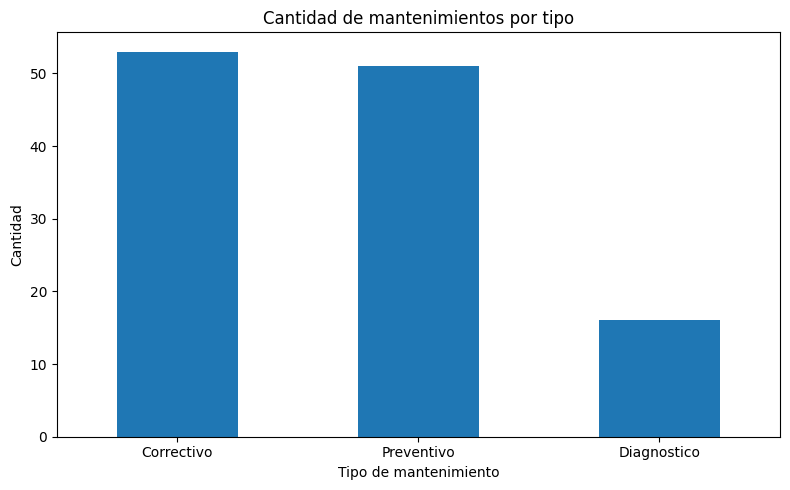

In [29]:
# Cantidad de mantenimientos por tipo
cantidad_por_tipo = df_limpio["tipo_mantenimiento"].value_counts()

# Crear gráfico
plt.figure(figsize=(8, 5))
cantidad_por_tipo.plot(kind="bar")

plt.title("Cantidad de mantenimientos por tipo")
plt.xlabel("Tipo de mantenimiento")
plt.ylabel("Cantidad")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

In [30]:
# Crear resumen por área
resumen_por_area = df_limpio.groupby("area").agg(
    cantidad_mantenimientos=("codigo", "count"),
    costo_total=("costo", "sum"),
    costo_promedio=("costo", "mean")
).reset_index()

# Redondear valores
resumen_por_area["costo_total"] = resumen_por_area["costo_total"].round(2)
resumen_por_area["costo_promedio"] = resumen_por_area["costo_promedio"].round(2)

resumen_por_area

,area,cantidad_mantenimientos,costo_total,costo_promedio
0,FADCOM,22,2050.67,93.21
1,FCNM,22,1992.48,90.57
2,FCSH,28,2070.91,73.96
3,FIEC,22,1767.78,80.35
4,FIMCP,13,1246.77,95.91
5,GTSI,13,1051.92,80.92


In [31]:
# Exportar DataFrame limpio
df_limpio.to_csv("mantenimientos_limpios.csv", index=False)

# Exportar resumen por área
resumen_por_area.to_csv("resumen_por_area.csv", index=False)

print("Archivos exportados correctamente.")

Archivos exportados correctamente.


In [32]:
df_errores = cargar_archivo("mantenimientos_con_errores.csv")

if df_errores is not None:
    print(df_errores.head())

Archivo cargado correctamente.
     codigo     equipo tipo_mantenimiento    area       fecha   costo  \
0  MNT-0001     Switch         Preventivo  FADCOM  2026-03-16   56.64   
1  MNT-0002     Router         Preventivo    GTSI  2026-01-28   53.86   
2  MNT-0003  Proyector         Preventivo   FIMCP  2026-03-17   83.42   
3  MNT-0004    Desktop         Preventivo    FCNM  2026-01-31   79.54   
4       NaN     Switch         Correctivo    GTSI  2026-04-11  117.38   

   duracion_horas       tecnico      estado  satisfaccion  
0             1.9    Ana Torres  En proceso             5  
1             2.3    Sofia Leon  Completado             1  
2             1.4  Maria Cedeño  Completado             5  
3             1.7    Ana Torres  Completado             5  
4             2.7    Ana Torres  Completado             4  


In [33]:
# Códigos vacíos
codigos_vacios_e = df_errores["codigo"].isna() | (
    df_errores["codigo"].astype(str).str.strip() == ""
)

# Códigos duplicados
codigos_duplicados_e = df_errores["codigo"].duplicated()

# Fechas inválidas
fechas_e = pd.to_datetime(df_errores["fecha"], errors="coerce")
fechas_invalidas_e = fechas_e.isna()

# Costos inválidos
costos_e = pd.to_numeric(df_errores["costo"], errors="coerce")
costos_no_numericos_e = costos_e.isna()
costos_negativos_e = costos_e < 0

# Duraciones inválidas
duraciones_e = pd.to_numeric(df_errores["duracion_horas"], errors="coerce")
duraciones_no_numericas_e = duraciones_e.isna()
duraciones_no_positivas_e = duraciones_e <= 0

# Satisfacción inválida
satisfaccion_e = pd.to_numeric(df_errores["satisfaccion"], errors="coerce")
satisfaccion_invalida_e = (
    satisfaccion_e.isna() |
    (satisfaccion_e < 1) |
    (satisfaccion_e > 5)
)

# Estados inválidos
estados_invalidos_e = ~df_errores["estado"].isin(estados_permitidos)

# Equipos inválidos
equipos_invalidos_e = ~df_errores["equipo"].isin(equipos_permitidos)

print("Códigos vacíos:", codigos_vacios_e.sum())
print("Códigos duplicados:", codigos_duplicados_e.sum())
print("Fechas inválidas:", fechas_invalidas_e.sum())
print("Costos no numéricos:", costos_no_numericos_e.sum())
print("Costos negativos:", costos_negativos_e.sum())
print("Duraciones no numéricas:", duraciones_no_numericas_e.sum())
print("Duraciones no positivas:", duraciones_no_positivas_e.sum())
print("Satisfacción inválida:", satisfaccion_invalida_e.sum())
print("Estados no permitidos:", estados_invalidos_e.sum())
print("Equipos no contemplados:", equipos_invalidos_e.sum())

Códigos vacíos: 1
Códigos duplicados: 1
Fechas inválidas: 1
Costos no numéricos: 1
Costos negativos: 1
Duraciones no numéricas: 0
Duraciones no positivas: 1
Satisfacción inválida: 1
Estados no permitidos: 1
Equipos no contemplados: 1


In [34]:
# Unir todos los errores encontrados
registros_invalidos_e = (
    codigos_vacios_e |
    codigos_duplicados_e |
    fechas_invalidas_e |
    costos_no_numericos_e |
    costos_negativos_e |
    duraciones_no_numericas_e |
    duraciones_no_positivas_e |
    satisfaccion_invalida_e |
    estados_invalidos_e |
    equipos_invalidos_e
)

# Excluir los registros que contienen errores
df_errores_limpio = df_errores[~registros_invalidos_e].copy()

print("Registros originales:", len(df_errores))
print("Registros con errores:", registros_invalidos_e.sum())
print("Registros válidos después de la limpieza:", len(df_errores_limpio))

Registros originales: 120
Registros con errores: 9
Registros válidos después de la limpieza: 111


In [35]:
# Prueba con un archivo que no existe
prueba_inexistente = cargar_archivo("archivo_que_no_existe.csv")

Error: el archivo no existe.
